<h1 style="text-align:center; font-weight:bold;">
A/B Testing Analysis: Does Website Background Color Affect Conversions?
</h1>


## Introduction
This project uses a synthetic A/B testing dataset generated with NumPy-based random sampling. The dataset simulates user interactions on an imaginary UK retail website. Users are assigned to two groups:

Group A (Control): Website with the default white background  
Group B (Treatment): Website with a new black background

The business question is:

Does changing the background color from white to black improve user engagement and conversions?

A/B testing provides a structured way to answer this question by comparing user behavior between the two groups and determining whether any observed differences are statistically significant.

The dataset includes the following columns:

User ID: Unique identifier for each visitor  
Group: Control (A) or treatment (B) assignment  
Page Views: Number of pages viewed during the session  
Time Spent: Total time spent on the website (in seconds)  
Conversion: Whether the user completed a desired action (0/1)  
Device: Device type used to access the website  
Location: User’s location within the UK

Beyond the A/B test, the dataset can also support deeper analysis, such as device-based or location-based user behavior patterns, making it useful for practicing real-world analytical skills.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest

In [4]:
# loading data
ab_data = pd.read_csv('data/ab_testing.csv')

#reformatting the column names
ab_data.columns = ab_data.columns.str.lower().str.replace(" ", "_")

#conversion 'Yes' and 'No' into 1 and 0 
ab_data['conversion'] = ab_data['conversion'].map({"Yes": 1, "No": 0})

print(ab_data.info())
print(ab_data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5000 non-null   int64 
 1   group       5000 non-null   object
 2   page_views  5000 non-null   int64 
 3   time_spent  5000 non-null   int64 
 4   conversion  5000 non-null   int64 
 5   device      5000 non-null   object
 6   location    5000 non-null   object
dtypes: int64(4), object(3)
memory usage: 273.6+ KB
None
   user_id group  page_views  time_spent  conversion   device  \
0    14292     B           3         424           0   Mobile   
1    11682     A           9         342           0   Mobile   
2    19825     A           2         396           0  Desktop   
3    16080     B           4         318           0  Desktop   
4    18851     A           1         338           1  Desktop   

           location  
0  Northern Ireland  
1          Scotland  
2  Northern Ireland 

In [7]:
## Basic analysis 
print(ab_data.isnull().sum(), "\n")
print(ab_data.duplicated().sum())

user_id       0
group         0
page_views    0
time_spent    0
conversion    0
device        0
location      0
dtype: int64 

0


### Exploratory data analysis (EDA)

In [10]:
print(ab_data['group'].value_counts(), '\n')
print(ab_data['device'].value_counts(), '\n')
print(ab_data['location'].value_counts())

group
A    2519
B    2481
Name: count, dtype: int64 

device
Desktop    2538
Mobile     2462
Name: count, dtype: int64 

location
Scotland            1281
England             1246
Northern Ireland    1242
Wales               1231
Name: count, dtype: int64


In [24]:
# conversion_rate = ab_data.groupby('group')['conversion'].mean())
print(ab_data.groupby('group')['conversion'].mean())
print(ab_data['conversion'].value_counts())

group
A    0.053990
B    0.140669
Name: conversion, dtype: float64
conversion
0    4515
1     485
Name: count, dtype: int64


In [14]:
print(ab_data.groupby('device')['conversion'].mean())
print(ab_data.groupby('location')['conversion'].mean())

device
Desktop    0.099685
Mobile     0.094232
Name: conversion, dtype: float64
location
England             0.109149
Northern Ireland    0.082931
Scotland            0.097580
Wales               0.098294
Name: conversion, dtype: float64


The conversion rate by devices and locations are not much significant, compared to that by groups.

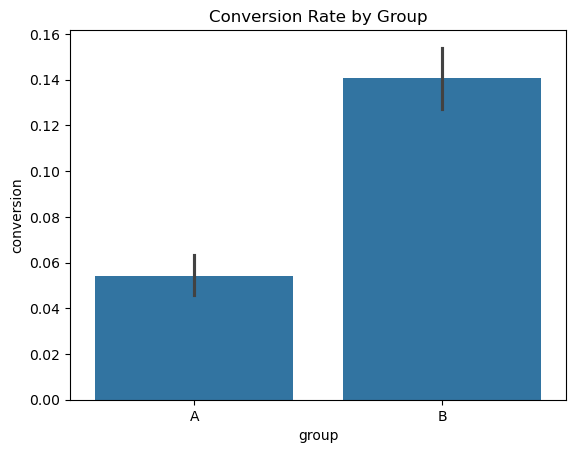

In [17]:
# Visualization
sns.barplot(ab_data, x="group", y="conversion", order=["A", "B"])
plt.title("Conversion Rate by Group")
plt.show()

## A/B Test — Two-sample Z-test for proportions


Our task is to know whether the new page leads to a higher (or lower) conversion rate than the old page. This is a two-sided test.

To answer this, we use hypothesis testing:

Null Hypothesis (H₀) - there is no difference in conversion rate: old = new  
Alternative Hypothesis (H₁) - there is a difference in conversion rates: old != new

 nobs = total number of users in each group (“number of observations”)
 successes = number of users who converted  

        |-------------------------|----------------------|-----------------------------|
        |   group	              |  nobs (# users)	     |  successes (# conversion)   |
        |-------------------------|----------------------|-----------------------------|
        | A - control (old page)  |  N_control           |   C_control                 |
        | B - treatment (new page)|  N_treatment         |   C_treatment               |
        |-------------------------|----------------------|-----------------------------|

These two arrays get passed into the Z-test.

Our data is binary (not continous data):   converted → 1;  not converted → 0
For this we use Z-test (not t-test).

Note: 
We cannot use t-test because it works better for comparing means of continuous data (such as comparing average time, comparing heights)


In [21]:

# We use hypothesis testing:

# Null Hypothesis (H0) - there is no difference in conversion rate: old = new  
# Alternative Hypothesis (H1) - there is a difference in conversion rates: old != new

# successes = number of users in each group who converted
successes = ab_data.groupby('group')['conversion'].sum().loc[['B', 'A']].values
print(f'Number of conversions: \n {successes}, \n')

# nobs = total number of users in each group (“number of observations”)
nobs = ab_data.groupby('group')['conversion'].count().loc[['B', 'A']].values
print(f'Number of observations: \n {nobs}')

# These two arrays (successes and nobs) get passed into the Z-test.

# Z-test
z_stat, p_value = proportions_ztest(successes, nobs)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

alpha = 0.05  # threshold value (significance level)

if p_value >= alpha:
    print("Fail to reject H0: No statistically significant difference.")
else:
    print("Reject H0: There IS a statistically significant difference.")


Number of conversions: 
 [349 136], 

Number of observations: 
 [2481 2519]
Z-statistic: 10.354488520266216
p-value: 3.9931511894201938e-25
Reject H0: There IS a statistically significant difference.


## Summary of Findings

After validating the A/B test design, we compared conversion rates between the control (A) and treatment (B) groups.
We performed a two-proportion Z-test with the following hypotheses:

H₀ (Null Hypothesis): The old and new pages have equal conversion rates.
H₁ (Alternative Hypothesis): The conversion rates differ between the two pages.

Test Results:

Conversion rate A (control): 5.40%
Conversion rate B (treatment): 14.07%

Z-statistic: 10.354
p-value: 3.99 × 10⁻²⁵
α = 0.05

The p-value is far below 0.05, so we reject the null hypothesis.

Interpretation:

There is a statistically significant difference in conversion rates between the two groups.
Since group B has a much higher conversion rate than group A, the new page significantly outperforms the old page.

## Final Conclusion

Based on this experiment, the company has strong evidence that the new page leads to higher conversions, and adopting the new page would likely improve user engagement.